# **dlt (Data Load Tool)**

## 📚 Table of Contents

- [Introduction](#introduction)
- [Overview](#overview)
- [Extracting Data with dlt: dlt RestAPI Client](#extracting-data-with-dlt-dlt-restapi-client)
- [dlt Resources](#dlt-resources)
- [How to Configure Secrets](#how-to-configure-secrets)
- [Normalizing Data with dlt](#normalizing-data-with-dlt)
- [Data Contracts](#data-contracts)
- [Alerting Schema Changes](#alerting-schema-changes)
- [Loading Data with dlt](#loading-data-with-dlt)
- [Write Dispositions](#write-dispositions)
- [Incremental Loading](#incremental-loading)
- [Loading Data from SQL Database to SQL Database](#loading-data-from-sql-database-to-sql-database)
- [Backfilling](#backfilling)
- [SCD2](#scd2)
- [Performance Tuning](#performance-tuning)
- [Loading Data to Data Lakes & Lakehouses & Catalogs](#loading-data-to-data-lakes--lakehouses--catalogs)
- [Loading Data to Warehouses/MPPs, Staging](#loading-data-to-warehousesmpps-staging)
- [Deployment & Orchestration](#deployment--orchestration)
- [Deployment with Git Actions](#deployment-with-git-actions)
- [Deployment with Crontab](#deployment-with-crontab)
- [Deployment with Dagster](#deployment-with-dagster)
- [Deployment with Airflow](#deployment-with-airflow)
- [Create Pipelines with LLMs: Understanding the Challenge](#create-pipelines-with-llms-understanding-the-challenge)
- [Create Pipelines with LLMs: Creating Prompts and LLM-Friendly Documentation](#create-pipelines-with-llms-creating-prompts-and-llm-friendly-documentation)
- [Create Pipelines with LLMs: Demo](#create-pipelines-with-llms-demo)

## Introduction




### What is dlt?

`dlt` (data load tool) is a Python-native data loading framework designed to build **production-grade data ingestion pipelines** easily.

It focuses on:

* extracting data from APIs, files, or databases
* transforming and normalizing data
* loading data into destinations (DuckDB, BigQuery, Snowflake, etc.)
* handling schema evolution automatically

---

### Core idea

Instead of writing complex ETL code manually, `dlt` allows you to:

> "Define data sources as Python functions and let the framework handle loading, schema, and state"

---

### Key components

#### 1. Source

A source defines **where data comes from**.

Example:

* REST API
* database
* file system

---

#### 2. Resource

A resource is a **data generator** that yields records.

Example:

```python
import dlt

@dlt.resource
def users():
    yield {"id": 1, "name": "Ahmed"}
```

---

#### 3. Pipeline

A pipeline defines:

* destination
* dataset name
* execution logic

Example:

```python
pipeline = dlt.pipeline(
    pipeline_name="my_pipeline",
    destination="duckdb",
    dataset_name="demo"
)
```

---

#### 4. Destination

Where data is stored:

* DuckDB
* BigQuery
* Snowflake
* Postgres

---

### How dlt works (flow)

1. Extract data from source
2. Normalize data (flatten JSON, create tables)
3. Infer schema automatically
4. Validate and type data
5. Load into destination
6. Track state for incremental loads

---

### Example: simple dlt pipeline

```python
import dlt
import requests

@dlt.resource
def github_events():
    url = "https://api.github.com/repos/DataTalksClub/data-engineering-zoomcamp/events"
    response = requests.get(url)
    yield from response.json()

pipeline = dlt.pipeline(
    pipeline_name="github_pipeline",
    destination="duckdb",
    dataset_name="github_data"
)

load_info = pipeline.run(github_events())
print(load_info)
```

---

### Automatic features in dlt

#### 1. Schema inference

* detects fields automatically
* creates tables
* adapts to changes

---

#### 2. Data normalization

* flattens nested JSON
* creates child tables for arrays

---

#### 3. Incremental loading

* tracks last processed data
* loads only new/updated records

---

#### 4. State management

* stores pipeline progress
* supports checkpointing

---

#### 5. Idempotent loading

* avoids duplicates
* supports safe re-runs

---

### dlt vs traditional ETL

| Feature           | Traditional ETL | dlt              |
| ----------------- | --------------- | ---------------- |
| Schema handling   | Manual          | Automatic        |
| JSON handling     | Complex         | Built-in         |
| State tracking    | Manual          | Built-in         |
| Incremental loads | Custom logic    | Built-in support |
| Setup time        | High            | Low              |

---

### When to use dlt

Use dlt when:

* building data ingestion pipelines
* working with APIs (like GitHub, Stripe, etc.)
* handling nested JSON data
* needing fast prototyping with production features

---

### Limitations

* not a full orchestration tool (use Airflow/Prefect for scheduling)
* less control compared to fully custom pipelines
* learning curve for advanced features

---

### Best practices

* keep resources small and composable
* use incremental loading where possible
* validate critical fields
* monitor schema changes
* separate raw and transformed data

---

### Key takeaway

`dlt` is designed to:

> "Turn Python data generators into production-ready data pipelines with minimal effort"

It abstracts away complexity while still allowing control, making it ideal for:

* data engineers
* backend engineers working with data
* AI engineers building data pipelines


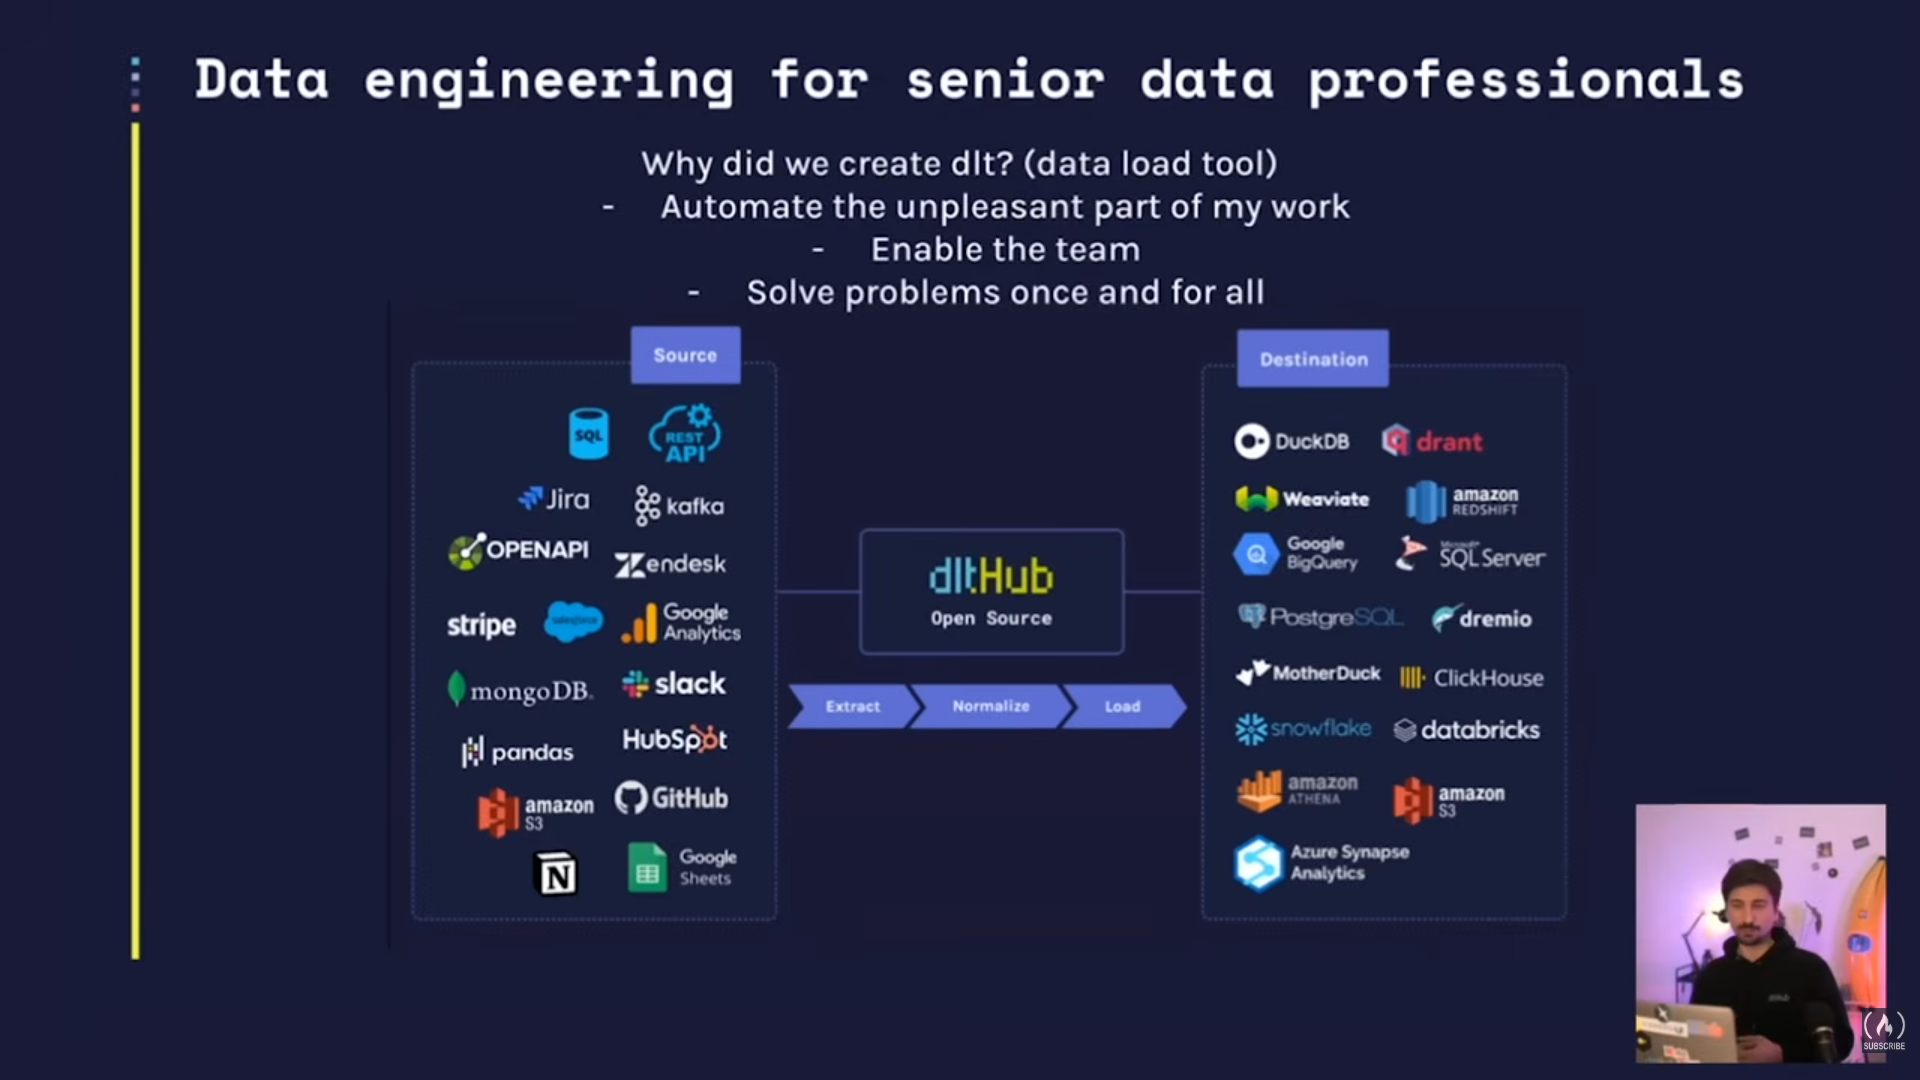

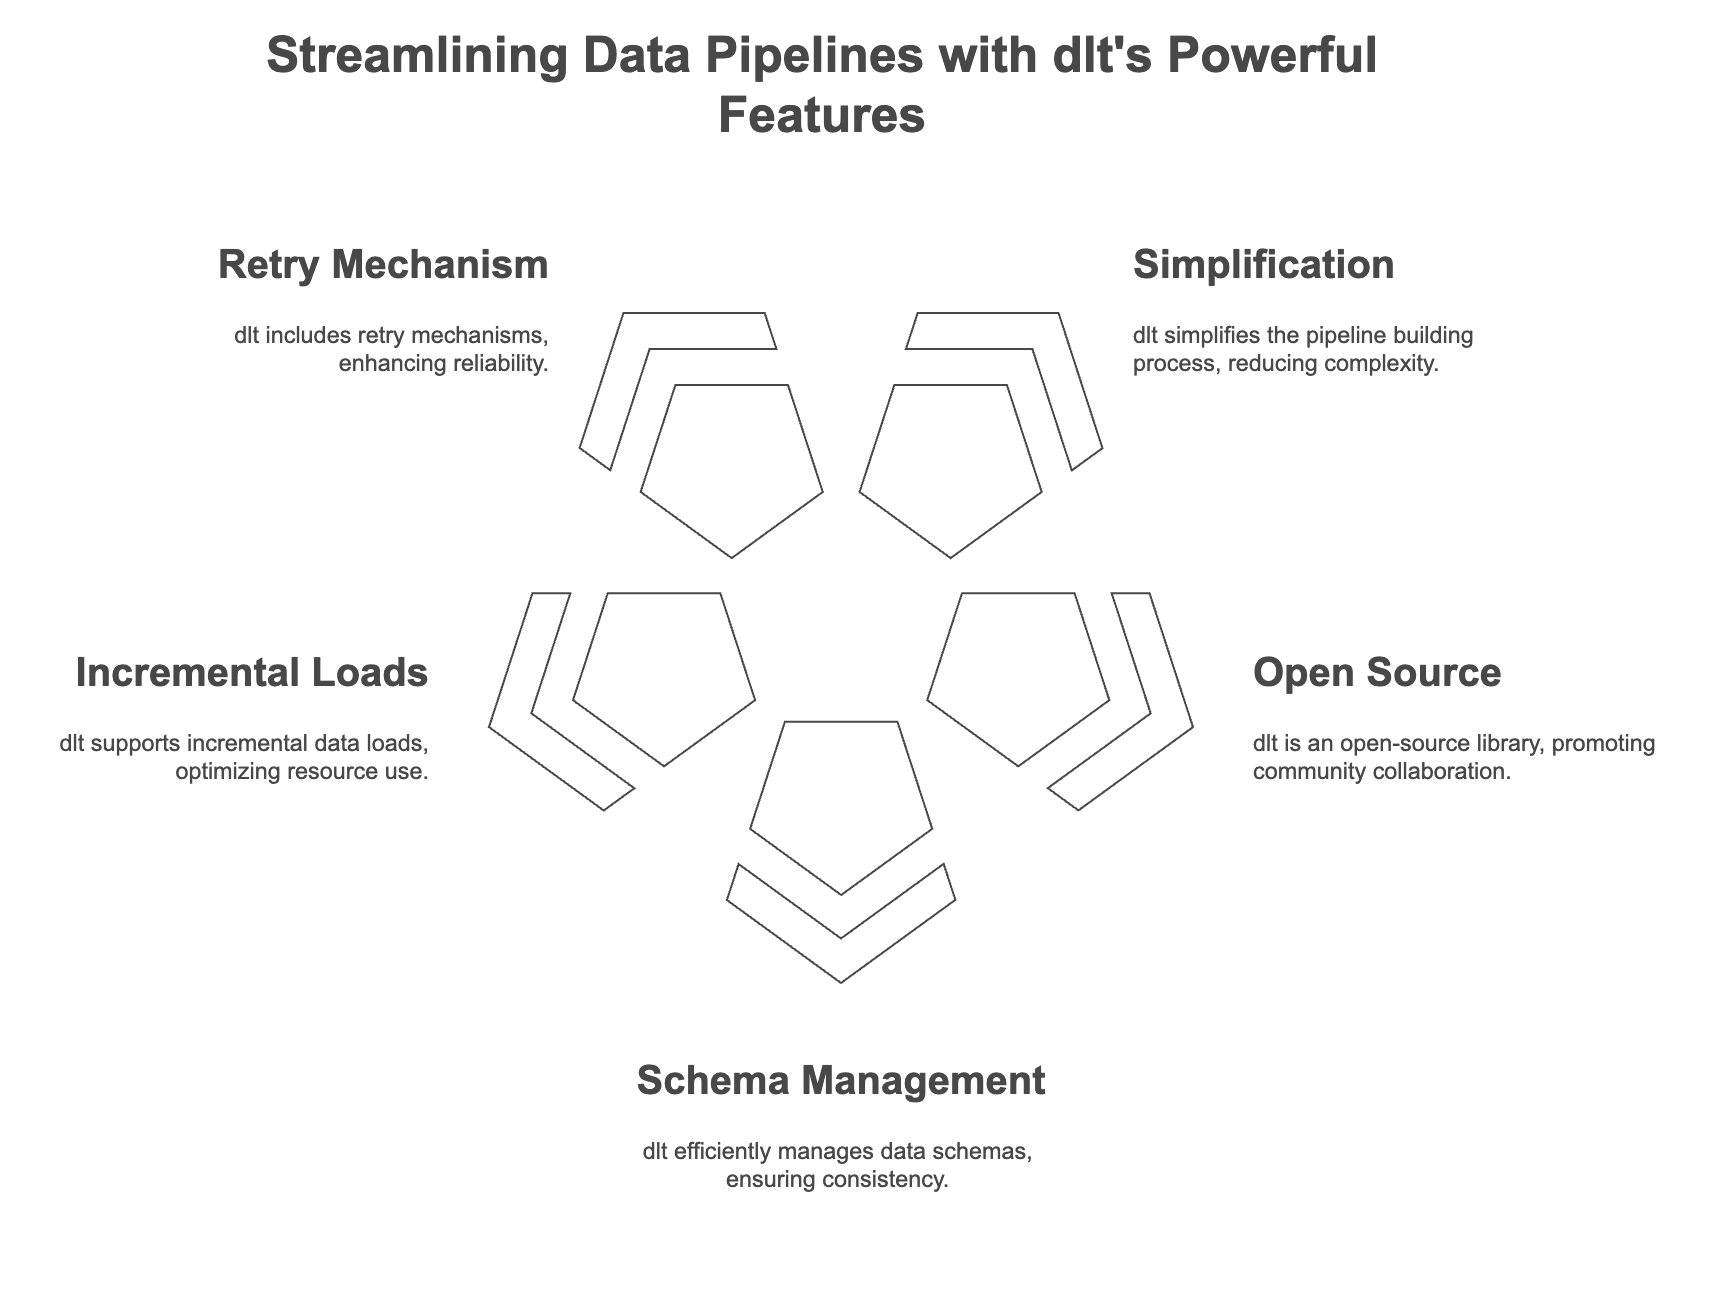


## Extracting Data with dlt: dlt RestAPI Client



Extracting data from APIs manually requires handling
- **pagination**,
- **rate limits**,
- **authentication**,
- **errors**.

Instead of writing custom scripts, **[dlt](https://dlthub.com/)** simplifies the process with a built-in **[REST API Client](https://dlthub.com/docs/general-usage/http/rest-client)**, making extraction **efficient, scalable, and reliable**.  

### **What is the dlt Rest Client?**
It's a declarative API client that can handle:
- automatic pagination
- various authentication mechanisms
- customizable request/response
- retries
---

### **Why use dlt for extraction?**  

✅ **Built-in REST API support** – Extract data from APIs with minimal code.  
✅ **Automatic pagination handling** – No need to loop through pages manually.  
✅ **Manages Rate Limits & Retries** – Prevents exceeding API limits and handles failures.  
✅ **Streaming support** – Extracts and processes data without loading everything into memory.  
✅ **Seamless integration** – Works with **normalization and loading** in a single pipeline.  


### Recap: In the previous part

📌 Example:

>In this example, we’ll request data from [GitHub API](https://docs.github.com/en/rest/quickstart?apiVersion=2022-11-28).

When calling a GitHub API endpoint, such as fetching events from the `data-engineering-zoomcamp` repository, GitHub paginates the results, meaning it returns only a limited number of records per request. By default, this is **30 results per page**, even if more data is available. To get all results, we need to request additional pages until there are no more left.

**API [documentation](https://docs.github.com/en/rest/activity/events?apiVersion=2022-11-28#list-repository-events)**:  
- **Endpoint**: `/repos/{owner}/{repo}/events`, lists repository events.
- **Data**: List of dicts. Comes in pages of 30 records.  
- **Pagination**: When there’s no more data, the API returns no links to the next page.  
- **Details**:  
  - **Method**: GET  
  - **URL**: `https://api.github.com/repos/DataTalksClub/data-engineering-zoomcamp/events`  
  - **Parameters**:  
    - `page`: Integer (page number), defaults to 1.
    - `per_page`: The number of results per page (max 100). Defaults to 30.  

>When a response is paginated, the response headers will include a `link` header. If the endpoint does not support pagination, or if all results fit on a single page, the link header will be omitted.
>
>The link header contains URLs that you can use to fetch additional pages of results. For example, the previous, next, first, and last page of results.


This script demonstrates how to handle paginated responses by automatically requesting the next page of data until all pages are retrieved:

In [2]:
import os
import requests
from dotenv import load_dotenv

# Load environment variables from .env
load_dotenv()

# Get token securely
API_TOKEN = os.getenv("GITHUB_TOKEN")

if not API_TOKEN:
    raise ValueError("GITHUB_TOKEN not found in environment variables")

BASE_URL = "https://api.github.com/repos/DataTalksClub/data-engineering-zoomcamp/events"


def paginated_getter():
    url = BASE_URL

    while True:
        response = requests.get(
            url,
            headers={"Authorization": f"Bearer {API_TOKEN}"},
            timeout=10
        )

        response.raise_for_status()  # fail fast if API error

        page_data = response.json()
        yield page_data

        # GitHub pagination via Link headers
        next_page = response.links.get("next", {}).get("url")

        if not next_page:
            break

        url = next_page


# Run
for page_data in paginated_getter():
    print(page_data)

[{'id': '8570973181', 'type': 'WatchEvent', 'actor': {'id': 211162749, 'login': 'jacobus27', 'display_login': 'jacobus27', 'gravatar_id': '', 'url': 'https://api.github.com/users/jacobus27', 'avatar_url': 'https://avatars.githubusercontent.com/u/211162749?'}, 'repo': {'id': 419661684, 'name': 'DataTalksClub/data-engineering-zoomcamp', 'url': 'https://api.github.com/repos/DataTalksClub/data-engineering-zoomcamp'}, 'payload': {'action': 'started'}, 'public': True, 'created_at': '2026-04-19T14:06:40Z', 'org': {'id': 72699292, 'login': 'DataTalksClub', 'gravatar_id': '', 'url': 'https://api.github.com/orgs/DataTalksClub', 'avatar_url': 'https://avatars.githubusercontent.com/u/72699292?'}}, {'id': '8569991548', 'type': 'ForkEvent', 'actor': {'id': 69511827, 'login': 'Gazir-it', 'display_login': 'Gazir-it', 'gravatar_id': '', 'url': 'https://api.github.com/users/Gazir-it', 'avatar_url': 'https://avatars.githubusercontent.com/u/69511827?'}, 'repo': {'id': 419661684, 'name': 'DataTalksClub/dat

**What happens here:**  

- Starts at **page 1** and makes a **GET request** to the API.  
- Retrieves **JSON data**.  
- Looks for the **"next" page URL** in the response headers.  
- If a **next page exists**, updates `BASE_URL` and requests more data.  
- If there’s **no next page**, stops fetching and ends the loop.

Now, let’s use dlt’s **RESTClient** to extract the same data, while exploring how it manages authentication and handles pagination automatically:

In [3]:
import os
import dlt
from dotenv import load_dotenv
from dlt.sources.helpers.rest_client import RESTClient
from dlt.sources.helpers.rest_client.auth import BearerTokenAuth
from dlt.sources.helpers.rest_client.paginators import HeaderLinkPaginator

# Load variables from .env file
load_dotenv()

# Read GitHub token from environment
API_TOKEN = os.getenv("GITHUB_TOKEN")

if not API_TOKEN:
    raise ValueError("GITHUB_TOKEN not found in .env file or environment variables")


def paginated_getter():
    client = RESTClient(
        base_url="https://api.github.com/repos/DataTalksClub/data-engineering-zoomcamp/",
        auth=BearerTokenAuth(token=API_TOKEN),
        paginator=HeaderLinkPaginator(
            links_next_key="next"
        ),  # GitHub uses Link headers for pagination
    )

    # API endpoint for retrieving repository events
    for page in client.paginate("events"):
        yield page  # yield pages one by one to avoid loading everything into memory


for page_data in paginated_getter():
    print(page_data)

[{'id': '8570973181', 'type': 'WatchEvent', 'actor': {'id': 211162749, 'login': 'jacobus27', 'display_login': 'jacobus27', 'gravatar_id': '', 'url': 'https://api.github.com/users/jacobus27', 'avatar_url': 'https://avatars.githubusercontent.com/u/211162749?'}, 'repo': {'id': 419661684, 'name': 'DataTalksClub/data-engineering-zoomcamp', 'url': 'https://api.github.com/repos/DataTalksClub/data-engineering-zoomcamp'}, 'payload': {'action': 'started'}, 'public': True, 'created_at': '2026-04-19T14:06:40Z', 'org': {'id': 72699292, 'login': 'DataTalksClub', 'gravatar_id': '', 'url': 'https://api.github.com/orgs/DataTalksClub', 'avatar_url': 'https://avatars.githubusercontent.com/u/72699292?'}}, {'id': '8569991548', 'type': 'ForkEvent', 'actor': {'id': 69511827, 'login': 'Gazir-it', 'display_login': 'Gazir-it', 'gravatar_id': '', 'url': 'https://api.github.com/users/Gazir-it', 'avatar_url': 'https://avatars.githubusercontent.com/u/69511827?'}, 'repo': {'id': 419661684, 'name': 'DataTalksClub/dat



### REST Client Authentication Strategies

---


#### 1. Overview

Modern REST clients support multiple authentication mechanisms to securely communicate with APIs.

The `auth` parameter allows plugging different authentication strategies depending on the API requirements.

Supported strategies:

* Bearer Token Authentication
* API Key Authentication
* HTTP Basic Authentication
* OAuth2 Client Credentials

---

#### 2. Bearer Token Authentication

##### Definition

Uses a token (usually JWT) passed in the Authorization header.

##### How it works

```http
Authorization: Bearer <token>
```

##### Characteristics

* Stateless
* Widely used in modern APIs
* Token issued after login/authentication

##### Example (Python)

```python
headers = {
    "Authorization": "Bearer YOUR_TOKEN"
}
```

##### Use Cases

* Secure APIs
* Microservices communication
* OAuth-based systems

---

#### 3. API Key Authentication

##### Definition

Uses a static key provided by the API provider.

##### How it works

Can be passed in:

* Headers
* Query parameters

###### Example

```http
GET /data?api_key=123456
```

or

```http
x-api-key: 123456
```

##### Characteristics

* Simple to implement
* Less secure than OAuth
* No user context

##### Use Cases

* Public APIs
* Internal services

---

#### 4. HTTP Basic Authentication

##### Definition

Uses username and password encoded in Base64.

##### How it works

```http
Authorization: Basic base64(username:password)
```

##### Example (Python)

```python
from requests.auth import HTTPBasicAuth

response = requests.get(url, auth=HTTPBasicAuth("user", "pass"))
```

##### Characteristics

* Very simple
* Requires HTTPS (otherwise insecure)

##### Use Cases

* Legacy systems
* Internal tools

---

#### 5. OAuth2 Client Credentials

##### Definition

A machine-to-machine authentication flow.

##### Flow

1. Client sends client_id and client_secret
2. Authorization server returns access token
3. Client uses token in requests

##### Example Flow

```http
POST /oauth/token
{
  "client_id": "abc",
  "client_secret": "xyz",
  "grant_type": "client_credentials"
}
```

Then:

```http
Authorization: Bearer <access_token>
```

##### Characteristics

* Secure
* Token-based
* No user interaction

##### Use Cases

* Microservices
* Backend-to-backend communication

---

#### 6. Comparison Table

| Method                    | Security  | Complexity | Use Case                   |
| ------------------------- | --------- | ---------- | -------------------------- |
| Bearer Token              | High      | Medium     | Modern APIs                |
| API Key                   | Medium    | Low        | Public APIs                |
| HTTP Basic                | Low       | Low        | Legacy systems             |
| OAuth2 Client Credentials | Very High | High       | Service-to-service systems |

---

#### 7. When to Use What

* Use Bearer Token → when you already have authentication system
* Use API Key → for simple access control
* Use Basic Auth → only for internal or legacy
* Use OAuth2 → for production-grade secure systems

---

#### 8. Key Takeaways

* Authentication method depends on system requirements
* OAuth2 and Bearer tokens dominate modern architectures
* API Keys are simple but limited
* Basic Auth should be avoided in production unless secured with HTTPS

👉 In production AI/data platforms, OAuth2 + Bearer Token is the standard approach.


## dlt Resources
## How to Configure Secrets
## Normalizing Data with dlt
## Data Contracts
## Alerting Schema Changes
## Loading Data with dlt
## Write Dispositions
## Incremental Loading
## Loading Data from SQL Database to SQL Database
## Backfilling
## SCD2
## Performance Tuning
## Loading Data to Data Lakes & Lakehouses & Catalogs
## Loading Data to Warehouses/MPPs, Staging
## Deployment & Orchestration
## Deployment with Git Actions
## Deployment with Crontab
## Deployment with Dagster
## Deployment with Airflow
## Create Pipelines with LLMs: Understanding the Challenge
## Create Pipelines with LLMs: Creating Prompts and LLM-Friendly Documentation
## Create Pipelines with LLMs: Demo